Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
!pip install clean-text
from cleantext import clean
import re
from transformers import XLNetTokenizer,XLNetForSequenceClassification,TrainingArguments,Trainer,pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
!pip install evaluate
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [2]:
#reading the datasets
data_train = pd.read_csv('emotion-labels-train.csv')
data_test = pd.read_csv('emotion-labels-test.csv')
data_val = pd.read_csv('emotion-labels-val.csv')

In [3]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [4]:
# cleaning the text by removing punctutations and emojis using cleantext lib
data = pd.concat([data_train,data_test,data_val],ignore_index=True)
data['clean_text'] = data['text'].apply(lambda x: clean(x,no_emoji=True,no_punct=True))
data.head()

,text,label,clean_text
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing garydelaney in bursl...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i dont...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,gardinerlove thank you so much gloria youre so...
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...


<Axes: xlabel='label'>

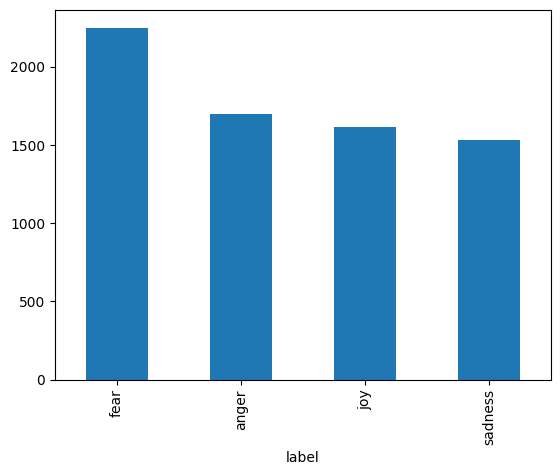

In [5]:
data['label'].value_counts().plot(kind='bar')

In [6]:
# smapling equal no.of data points of each label and dropping the old indices to avoid multi level indexing
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop=True)))

/tmp/ipykernel_205/3095673312.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

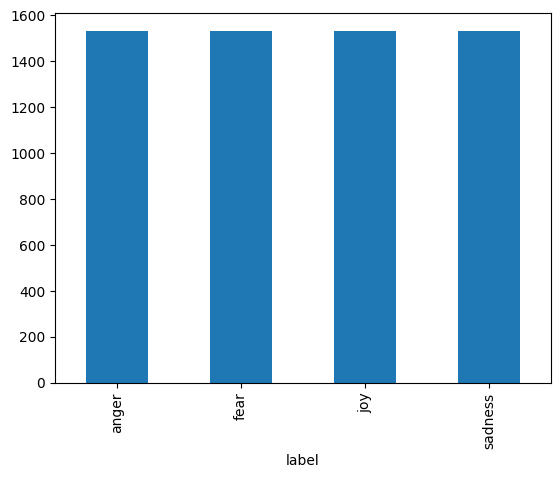

In [7]:
data['label'].value_counts().plot(kind='bar')

In [8]:
# converting labels into numeric labels using LabelEncoder
data['label_int'] = LabelEncoder().fit_transform(data['label'])
data.head()

text  label  \
label                                                               
anger 0  Mia has the worst road rage I have ever seen a...  anger   
      1  So my Indian Uber driver just called someone t...  anger   
      2  @DarkLuneFantasy wallah my blood is boiling I ...  anger   
      3  @AgentTinsley I believe that's what you call t...  anger   
      4  My irritation level is at an all time high tod...  anger   

                                                clean_text  label_int  
label                                                                  
anger 0  mia has the worst road rage i have ever seen a...          0  
      1  so my indian uber driver just called someone t...          0  
      2  darklunefantasy wallah my blood is boiling i n...          0  
      3  agenttinsley i believe thats what you call the...          0  
      4   my irritation level is at an all time high today          0

In [9]:
NUM_LABELS = 4

In [10]:
train_split,test_split = train_test_split(data,train_size=0.8)
train_split, val_split = train_test_split(train_split,train_size=0.9)
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [11]:
train_df = pd.DataFrame({
    "label" : train_split.label_int.values,
    "text" : train_split.clean_text.values
})

test_df = pd.DataFrame({
    "label" : test_split.label_int.values,
    "text" : test_split.clean_text.values
})

In [12]:
# converting pandas DataFrame into HuggingFace dataset using datasets lib
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

In [13]:
#Creating embeddings
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

def tokenize_func(inp):
  return tokenizer(inp["text"],padding="max_length",max_length=128,truncation=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

In [14]:
tokenized_datasets = dataset_dict.map(tokenize_func,batched=True)
tokenized_datasets

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [15]:
print(tokenized_datasets['train']['text'][0])

if someone keeps laughing at you dont fret at least u r giving happiness
quotes quotestoliveby


In [16]:
#input_ids: the numbers representing the tokens in the text.
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 108, 886, 5788, 9186, 38, 44, 220, 46, 22953, 38, 390, 17, 660, 17, 213, 1344, 9686, 8639, 8639, 261, 8032, 1164, 4, 3]


In [17]:
#token_type_ids: indicates which sequence a token belongs to if there is more than one sequence.
#attention_mask represents if mask should be applied to the token or not
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [18]:
tokenizer.decode(5)

'<pad>'

In [19]:
small_train_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(100))
small_test_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(100))

Fine tuning the model

In [21]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased',num_labels=NUM_LABELS,id2label={0 : 'anger',1 : 'fear',2 :'joy',3 : 'sadness'})

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
import evaluate
metric = evaluate.load("accuracy")

In [24]:
def compute_metrics(eval_pred):
  logits,labels = eval_pred
  predictions = np.argmax(logits,axis=-1)
  return metric.compute(predictions=predictions,references=labels)

In [25]:
training_args = TrainingArguments(output_dir="test_trainer",eval_strategy="epoch",num_train_epochs=3)

In [26]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = small_train_dataset,
    eval_dataset = small_test_dataset,
    compute_metrics = compute_metrics
)

In [27]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.506499,0.230000
2,No log,1.399063,0.240000
3,No log,1.394941,0.270000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=39, training_loss=1.4033094552847056, metrics={'train_runtime': 747.5011, 'train_samples_per_second': 0.401, 'train_steps_per_second': 0.052, 'total_flos': 21366375321600.0, 'train_loss': 1.4033094552847056, 'epoch': 3.0})

Evaluating the model

In [28]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.3949414491653442,
 'eval_accuracy': 0.27,
 'eval_runtime': 83.6765,
 'eval_samples_per_second': 1.195,
 'eval_steps_per_second': 0.155,
 'epoch': 3.0}

In [30]:
model.save_pretrained("fine_tuned_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [32]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [33]:
clf = pipeline("text-classification",fine_tuned_model,tokenizer=tokenizer)

In [34]:
rand_int = random.randint(0,len(val_split))
print(val_split['clean_text'][rand_int])
answer = clf(val_split['clean_text'][rand_int],top_k=None)
print(answer)

/tmp/ipykernel_205/3919715620.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(val_split['clean_text'][rand_int])
/tmp/ipykernel_205/3919715620.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  answer = clf(val_split['clean_text'][rand_int],top_k=None)


survivor is back survivormillennialsvsgenx so happy to see you jeffprobst
[{'label': 'sadness', 'score': 0.3423175811767578}, {'label': 'anger', 'score': 0.26091858744621277}, {'label': 'fear', 'score': 0.2086612582206726}, {'label': 'joy', 'score': 0.188102588057518}]
